# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(42)
n_rows = 500

#  5 Predictive Features
kd_ratio = np.random.uniform(0.5, 3.5, n_rows) # Kill/Death Ratio (Numeric)
hours_played = np.random.randint(50, 2000, n_rows) # Total account playtime (Numeric)
ping_ms = np.random.randint(15, 130, n_rows) # Network lag (Numeric)
role = np.random.choice(['DPS', 'Tank', 'Support'], n_rows) # Player class (Categorical)
mic_active = np.random.choice(['Yes', 'No'], n_rows) # Voice comms (Categorical)

# Calculating the Target Feature (Rank_Points) based on the stats
rank_points = 15 + (kd_ratio * 12) - (ping_ms * 0.15) 
rank_points += np.where(mic_active == 'Yes', 5, 0) # Buff for using a mic
rank_points += np.random.normal(0, 4, n_rows) # Adding some RNG variance

df = pd.DataFrame({
    'KD_Ratio': kd_ratio,
    'Total_Hours': hours_played,
    'Ping_ms': ping_ms,
    'Role': role,
    'Mic_Active': mic_active,
    'Rank_Points': rank_points
})

df.head()

,KD_Ratio,Total_Hours,Ping_ms,Role,Mic_Active,Rank_Points
0,1.623620,551,24,DPS,No,33.038468
1,3.352143,1008,19,Tank,No,48.693021
2,2.695982,1218,88,DPS,No,34.829225
3,2.295975,1274,111,DPS,Yes,25.246847
4,0.968056,978,52,Tank,Yes,23.371767


For this Exploratory Data Analysis. I engineered a dataset of 500 competitive ranked matches to analyze what actually drives a player's ability to climb the ladder.

The Target Feature: > * Rank_Points:
The total competitive points gained or lost after a match (Continuous numerical value). This is the primary metric we are trying to predict.

The 5 Predictive Features:

KD_Ratio: The player's kill-to-death ratio (Quantitative, ranging from 0.5 to 3.5).

Total_Hours: The total playtime on the player's account (Quantitative, ranging from 50 to 2000 hours).

Ping_ms: The network latency or lag during the match (Quantitative, ranging from 15ms to 130ms).

Role: The class the player selected (Categorical: 'DPS', 'Tank', or 'Support').

Mic_Active: Whether the player used voice comms (Categorical: 'Yes' or 'No').

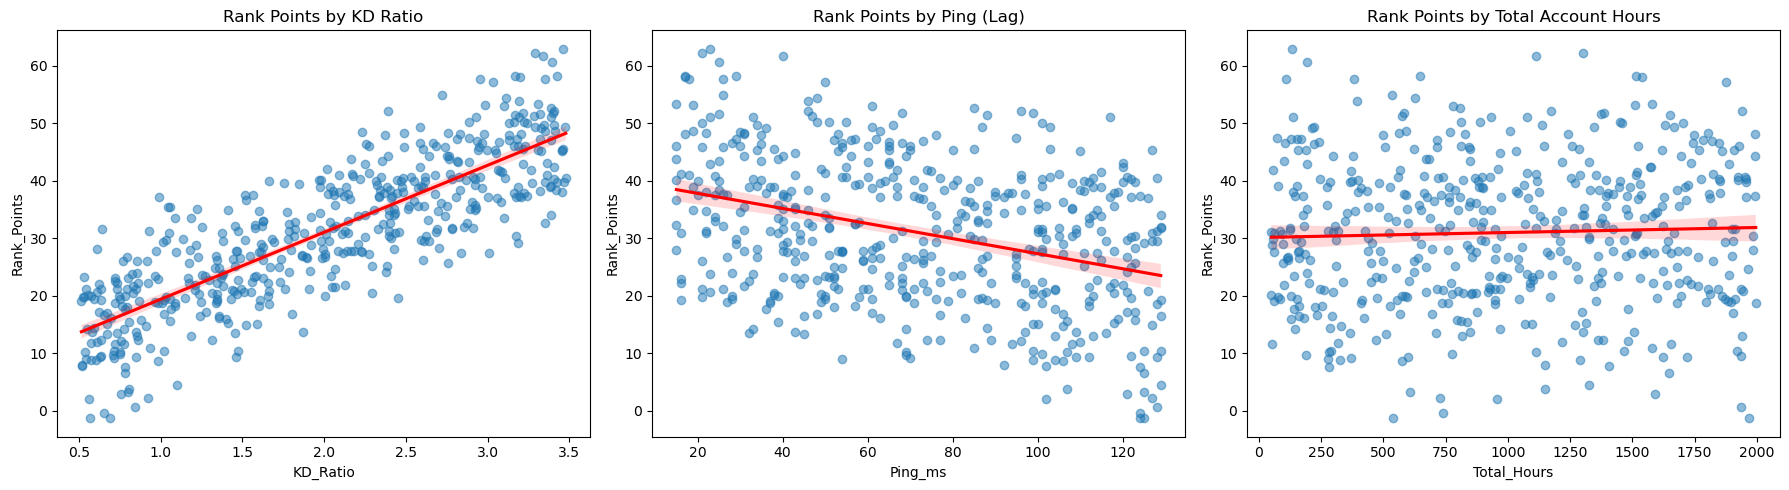

In [2]:
plt.figure(figsize=(18, 5))

# 1. KD Ratio vs Rank Points
plt.subplot(1, 3, 1)
sns.regplot(x='KD_Ratio', y='Rank_Points', data=df, line_kws={'color': 'red'}, scatter_kws={'alpha':0.5})
plt.title('Rank Points by KD Ratio')

# 2. Ping vs Rank Points
plt.subplot(1, 3, 2)
sns.regplot(x='Ping_ms', y='Rank_Points', data=df, line_kws={'color': 'red'}, scatter_kws={'alpha':0.5})
plt.title('Rank Points by Ping (Lag)')

# 3. Total Hours vs Rank Points
plt.subplot(1, 3, 3)
sns.regplot(x='Total_Hours', y='Rank_Points', data=df, line_kws={'color': 'red'}, scatter_kws={'alpha':0.5})
plt.title('Rank Points by Total Account Hours')

plt.tight_layout()
plt.show()

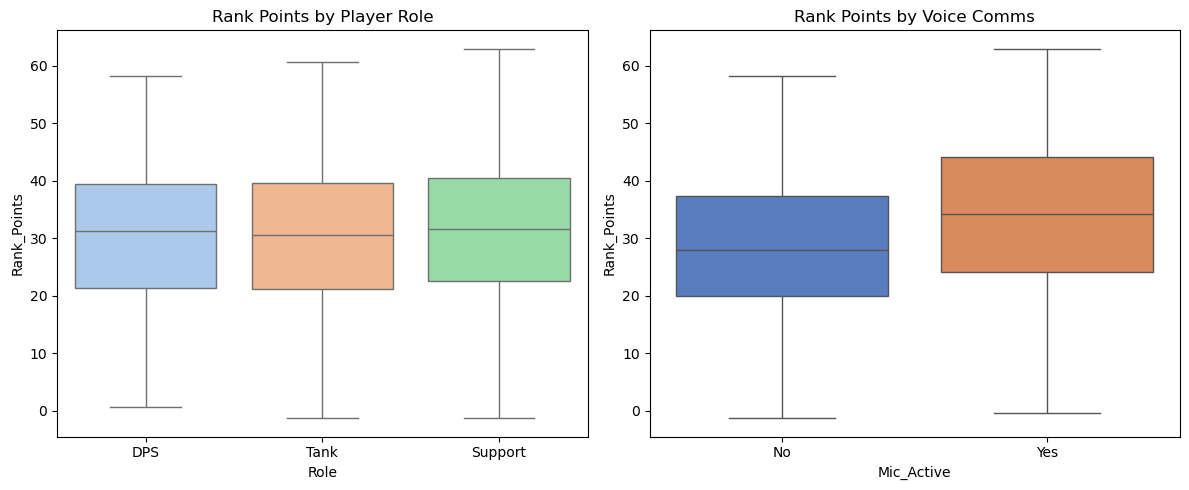

In [3]:
plt.figure(figsize=(12, 5))

# 4. Role vs Rank Points
plt.subplot(1, 2, 1)
sns.boxplot(x='Role', y='Rank_Points', data=df, hue='Role', palette='pastel', legend=False)
plt.title('Rank Points by Player Role')

# 5. Mic Active vs Rank Points
plt.subplot(1, 2, 2)
sns.boxplot(x='Mic_Active', y='Rank_Points', data=df, hue='Mic_Active', palette='muted', legend=False)
plt.title('Rank Points by Voice Comms')

plt.tight_layout()
plt.show()

Which features carry the data? (Strong Relationships)

KD_Ratio: This is the ultimate core stat. The regplot shows a massive positive correlation; as the player's mechanical skill (KD) scales up, their Rank Points scale with it perfectly.

Ping_ms: This acts as a heavy debuff. There is a clear negative correlation—the higher the lag, the lower the Rank Points gained.

Mic_Active: The boxplot proves that having voice comms active acts as a flat buff. The median Rank Points for players using microphones is visibly higher than those playing silently.

Which features are ignored? (No Influence)

Total_Hours: The scatterplot for total playtime is a completely flat, random cloud of data. This proves that account tenure is a trap stat; just grinding hours doesn't inherently make you climb the ranks faster.

Role: The medians and IQRs across DPS, Tank, and Support are practically identical. The algorithm is perfectly balanced across classes, meaning no single role carries an unfair advantage.

The Big Picture Takeaway:
If a player wants to min-max their competitive climb, they need to prioritize mechanical execution (KD Ratio) and ensure their hardware setup is optimal (low ping). Furthermore, simply playing the game for thousands of hours (Total_Hours) will not passively boost their rank. High-level execution and team communication actively drive the rank meta, while sheer playtime does not.